In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from gwgraphs import *
from scipy.stats import ttest_ind

In [2]:
def read_graph_data():
    # Read the adjacency matrix (edges)
    with open("BZR_A.txt", "r") as f:
        edges = [tuple(map(int, line.split(','))) for line in f]

    # Read graph indicators
    with open("BZR_graph_indicator.txt", "r") as f:
        graph_indicators = [int(line.strip()) for line in f if line.strip()]

    # Read graph labels
    with open("BZR_graph_labels.txt", "r") as f:
        graph_labels = [int(line.strip()) for line in f]

    # Read node labels
    with open("BZR_node_labels.txt", "r") as f:
        node_labels = [int(line.strip()) for line in f]

    return edges, graph_indicators, graph_labels, node_labels


def construct_networkx_graph(edges, graph_indicators, graph_labels,
                             node_labels):
    graphs = {}
    for node_id, graph_id in enumerate(graph_indicators, start=1):
        if graph_id not in graphs:
            graphs[graph_id] = nx.Graph(label=graph_labels[graph_id - 1])

    for edge in edges:
        node1, node2 = edge
        graph_id = graph_indicators[
            node1 - 1]  # Determine which graph the edge belongs to
        graphs[graph_id].add_edge(node1, node2)

    for node_id, (graph_id,
                  node_label) in enumerate(zip(graph_indicators, node_labels),
                                           start=1):
        graphs[graph_id].nodes[node_id]['label'] = node_label

    return graphs


def compute_averages(graphs):
    # Initialize variables
    total_nodes = 0
    class_nodes = {}
    class_counts = {}
    # Iterate through graphs to compute totals
    for graph_id, graph in graphs.items():
        num_nodes = graph.number_of_nodes()
        total_nodes += num_nodes
        
        # Get the class label for the current graph
        graph_label = graph.graph['label']
        
        if graph_label not in class_nodes:
            class_nodes[graph_label] = 0
            class_counts[graph_label] = 0
        
        class_nodes[graph_label] += num_nodes
        class_counts[graph_label] += 1
    # Calculate total average
    total_avg = round(total_nodes / len(graphs))
    
    # Calculate class-based averages
    class_averages = {label: round(class_nodes[label] / count)
                      for label, count in class_counts.items()}
    
    return total_avg, class_averages


def compute_bzr_distance_matrix(graph):
    num_nodes = len(graph.nodes)
    distance_matrix = np.full((num_nodes, num_nodes), 10000.0)

    # Get the correct node indices to be used for indexing the matrix
    node_list = list(graph.nodes())
    node_index = {node: i for i, node in enumerate(node_list)}

    for node in graph.nodes:
        lengths = nx.shortest_path_length(graph, source=node, weight="weight")

        for target, length in lengths.items():
            if target in node_index:
                distance_matrix[node_index[node], node_index[target]] = length

    return distance_matrix


def compute_graph_stats(graphs):
    # Initialize counters
    total_edges = 0
    total_nodes = 0
    class1_edges = 0
    class1_nodes = 0
    classm1_edges = 0
    classm1_nodes = 0

    # Collect degrees for plotting
    all_degrees = []
    class1_degrees = []
    classm1_degrees = []

    for graph in graphs.values():
        num_edges = graph.number_of_edges()
        num_nodes = graph.number_of_nodes()
        degrees = [d for n, d in graph.degree()]

        total_edges += num_edges
        total_nodes += num_nodes
        all_degrees.extend(degrees)

        if graph.graph['label'] == 1:
            class1_edges += num_edges
            class1_nodes += num_nodes
            class1_degrees.extend(degrees)
        else:
            classm1_edges += num_edges
            classm1_nodes += num_nodes
            classm1_degrees.extend(degrees)

    # Calculate statistics
    edge_density = (2 * total_edges) / (total_nodes * (total_nodes - 1))
    avg_degree = 2 * total_edges / total_nodes
    avg_degree_class1 = 2 * class1_edges / class1_nodes if class1_nodes > 0 else 0
    avg_degree_classm1 = 2 * classm1_edges / classm1_nodes if classm1_nodes > 0 else 0

    print(f"\nGraph Statistics:")
    print(f"Edge Density: {edge_density:.4f}")
    print(f"Average Degree (Full Dataset): {avg_degree:.2f}")
    print(f"Average Degree (Class 1): {avg_degree_class1:.2f}")
    print(f"Average Degree (Class -1): {avg_degree_classm1:.2f}")

    # Plot degree distributions

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Full dataset degree distribution
    ax1.hist(all_degrees, bins=30, alpha=0.7, color='blue', label='All')
    ax1.set_title('Degree Distribution (Full Dataset)')
    ax1.set_xlabel('Degree')
    ax1.set_ylabel('Frequency')
    ax1.legend()

    # Class-wise degree distribution
    bins = np.linspace(min(all_degrees), max(all_degrees), 31)
    class1_hist, _ = np.histogram(class1_degrees, bins=bins)
    classm1_hist, _ = np.histogram(classm1_degrees, bins=bins)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    width = (bins[1] - bins[0]) * 0.35

    ax2.bar(bin_centers - width/2, class1_hist, width, color='gray', label='Class 1')
    ax2.bar(bin_centers + width/2, classm1_hist, width, color='purple', label='Class -1')
    ax2.set_title('Degree Distribution by Class')
    ax2.set_xlabel('Degree')
    ax2.set_ylabel('Frequency')
    ax2.legend()

    plt.tight_layout()
    plt.savefig('degree_distributions.png')
    plt.show()
    plt.close()

In [3]:
edges, graph_indicators, graph_labels, node_labels = read_graph_data()
graphs = construct_networkx_graph(edges, graph_indicators, graph_labels,
                                      node_labels)
for graph_id, graph in graphs.items():
    print(
        f"Graph ID: {graph_id}, number of nodes: {graph.number_of_nodes()}, label: {graph.graph['label']}"
        )
total_avg, class_averages = compute_averages(graphs)
print(f"Average number of nodes in entire dataset: {total_avg}")
print("Average number of nodes for each class:")
for class_label, avg_nodes in class_averages.items():
        print(f"  Class {class_label}: {avg_nodes}")

Graph ID: 1, number of nodes: 30, label: -1
Graph ID: 2, number of nodes: 33, label: -1
Graph ID: 3, number of nodes: 30, label: -1
Graph ID: 4, number of nodes: 33, label: -1
Graph ID: 5, number of nodes: 30, label: -1
Graph ID: 6, number of nodes: 33, label: -1
Graph ID: 7, number of nodes: 30, label: -1
Graph ID: 8, number of nodes: 30, label: -1
Graph ID: 9, number of nodes: 33, label: -1
Graph ID: 10, number of nodes: 30, label: -1
Graph ID: 11, number of nodes: 30, label: -1
Graph ID: 12, number of nodes: 30, label: -1
Graph ID: 13, number of nodes: 33, label: -1
Graph ID: 14, number of nodes: 33, label: -1
Graph ID: 15, number of nodes: 33, label: -1
Graph ID: 16, number of nodes: 33, label: -1
Graph ID: 17, number of nodes: 32, label: -1
Graph ID: 18, number of nodes: 32, label: -1
Graph ID: 19, number of nodes: 32, label: -1
Graph ID: 20, number of nodes: 35, label: -1
Graph ID: 21, number of nodes: 32, label: -1
Graph ID: 22, number of nodes: 35, label: -1
Graph ID: 23, numbe

In [4]:
graphs_list = []
labels_list = []
for graph_id, graph in graphs.items():
    # Add the graph object to the list
    graphs_list.append(graph)

    # Extract the label and add to the label list
    label = graph.graph['label']
    labels_list.append(label)

# Convert graphs into pairwise distance matrices
distance_matrices = [compute_bzr_distance_matrix(graph) for graph in graphs_list]


Graph Statistics:
Edge Density: 0.0001
Average Degree (Full Dataset): 2.15
Average Degree (Class 1): 2.14
Average Degree (Class -1): 2.15


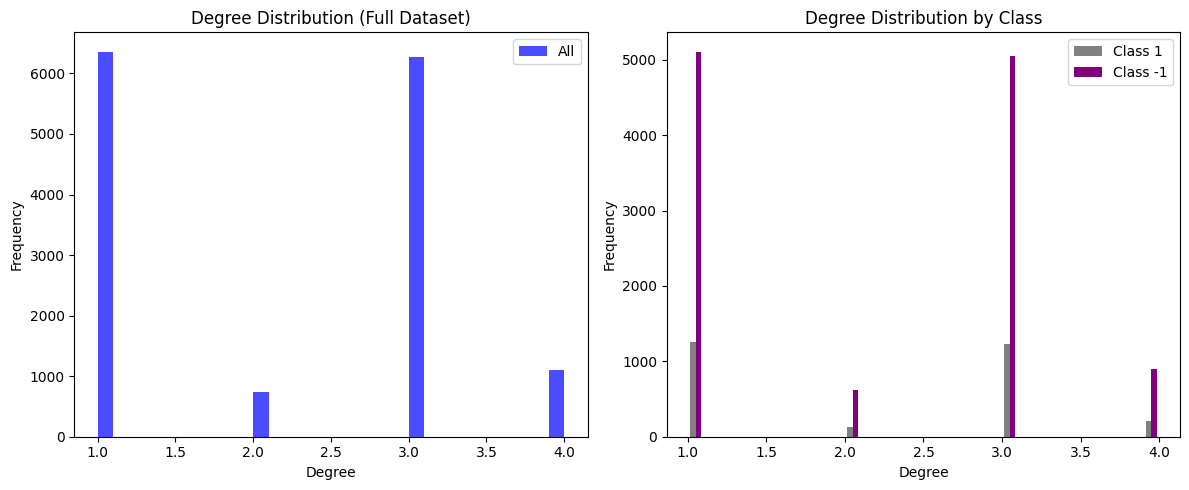

In [5]:
# Compute and display graph statistics
compute_graph_stats(graphs)

In [6]:
# ATTEMPT 1: Use the dataset's average # of nodes for the barycenters
bzr_exp = gw_barycenter_class_alg_var_nodes(distance_matrices,
                                                 labels_list,
                                                 num_folds=10,
                                                 num_nodes_negone=36,
                                                 num_nodes_one=36,
                                                 method="stratk")

Stratified k-fold CV selected
Fold 0:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.5141976347881185  Fold 0
F1 Score (weighted avg): 64.04878048780488%, Fold 0
Classification Accuracy: 60.97560975609756% Fold 0
Classification Accuracy for Class -1: 53.125% Fold 0
Classification Accuracy for Class 1: 88.88888888888889% Fold 0
Fold 1:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.4648098123888684  Fold 1
F1 Score (weighted avg): 42.80524872118022%, Fold 1
Classification Accuracy: 39.02439024390244% Fold 1
Classification Accuracy for Class -1: 34.375% Fold 1
Classification Accuracy for Class 1: 55.55555555555556% Fold 1
Fold 2:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.6263404217259936  Fold 2
F1 Score (weighted avg): 48.72018661630989%, Fold 2
Classification Accuracy: 43

In [7]:
# t-test for statistical significance of difference of the two means
# Collect class labels and number nodes for each class
class_labels = list(class_averages.keys())
nodes_per_class = {label: [] for label in class_labels}
for graph in graphs.values():
    graph_label = graph.graph['label']
    nodes_per_class[graph_label].append(graph.number_of_nodes())
# Perform the t-test between the two classes
if len(class_labels) > 1:
    class1_nodes = nodes_per_class[class_labels[0]]
    class2_nodes = nodes_per_class[class_labels[1]]
    t_stat, p_value = ttest_ind(class1_nodes, class2_nodes, equal_var=False)
    print(f"T-statistic: {t_stat}, P-value: {p_value}")
    if p_value < 0.05:
        print(
            "The difference between the two class means is statistically significant."
        )
    else:
        print(
            "The difference between the two class means is not statistically significant."
        )
else:
    print("Not enough classes to perform a t-test.")

T-statistic: 4.0012608663245475, P-value: 0.0001107166208890733
The difference between the two class means is statistically significant.


In [8]:
# ATTEMPT 2: Use the average # of nodes for each class to make the barycenters for each class
bzr_exp2 = gw_barycenter_class_alg_var_nodes(distance_matrices,
                                                 labels_list,
                                                 num_folds=10,
                                                 num_nodes_negone=37,
                                                 num_nodes_one=33,
                                                 method="stratk")

Stratified k-fold CV selected
Fold 0:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.5076804837854947  Fold 0
F1 Score (weighted avg): 59.55487804878049%, Fold 0
Classification Accuracy: 56.09756097560976% Fold 0
Classification Accuracy for Class -1: 50.0% Fold 0
Classification Accuracy for Class 1: 77.77777777777779% Fold 0
Fold 1:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.5453520759297293  Fold 1
F1 Score (weighted avg): 62.05469327420546%, Fold 1
Classification Accuracy: 58.536585365853654% Fold 1
Classification Accuracy for Class -1: 59.375% Fold 1
Classification Accuracy for Class 1: 55.55555555555556% Fold 1
Fold 2:
GW barycenter for Class -1 graphs computed
GW barycenter for Class 1 graphs computed
Distance between barycenters:  0.6394062064454347  Fold 2
F1 Score (weighted avg): 53.17930082358728%, Fold 2
Classification Accuracy: 48.